# YouTube Channel EDA — Three Approaches
This notebook performs exploratory data analysis using:
- **Option A:** Unique channels only (drop duplicates)
- **Option B:** Aggregated by channel
- **Option C:** Category-expanded dataset

Each section includes visualizations and insights.

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## 📥 Load Dataset

In [2]:
# Replace with actual filepath
df = pd.read_csv('cleaned_youtube_data_new_1.csv')
df.head()

,channel_name,view_count,category,country,subscriber_count,created_date,video_count,videos_last_30_days,views_last_30_days,view_count_log1p,subscriber_count_log1p,video_count_log1p,videos_last_30_days_log1p,views_last_30_days_log1p,channel_created_year,channel_age_years
0,BLACKPINK,39962585446,Music of Asia,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
1,BLACKPINK,39962585446,Pop music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
2,BLACKPINK,39962585446,Music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
3,BLACKPINK,39962585446,Electronic music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
4,HYBE LABELS,41604896923,Hip hop music,KR,78700000,2008-06-04 08:23:22+00:00,2817,79,46074833,24.451484,18.181154,7.943783,4.382027,17.645777,2008,17.43


# 🔹 Option A — Unique Channels Only

In [3]:
df_unique = df.drop_duplicates(subset=['channel_name'])
df_unique.shape

(15829, 16)

### Heatmap — Unique Channels

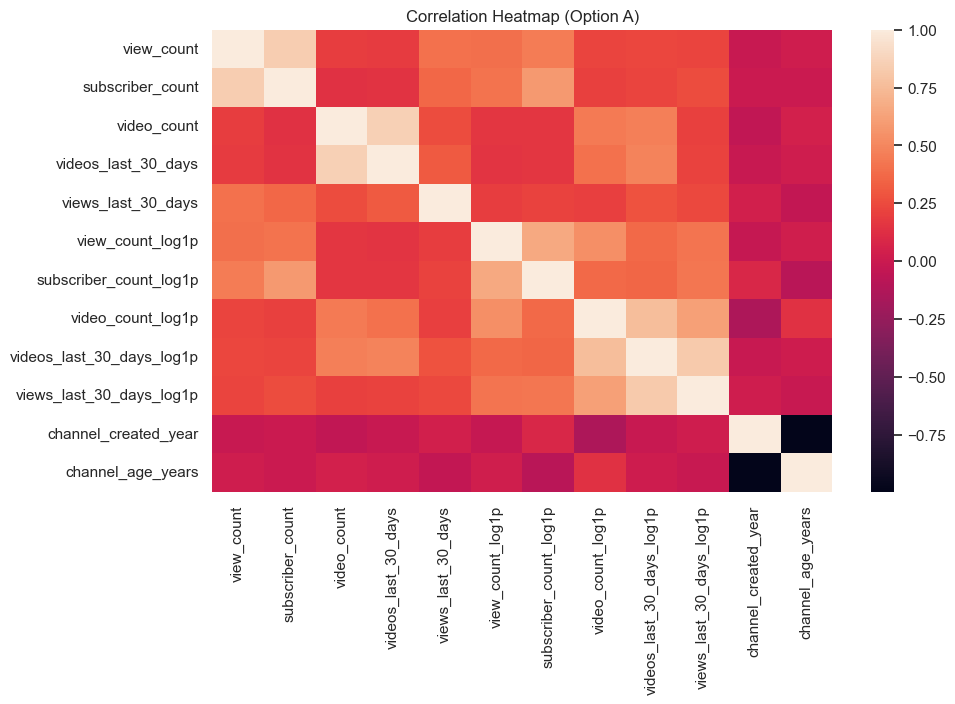

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df_unique.select_dtypes(include=np.number).corr(), annot=False)
plt.title("Correlation Heatmap (Option A)")
plt.show()

### Scatter: Subscribers vs Views

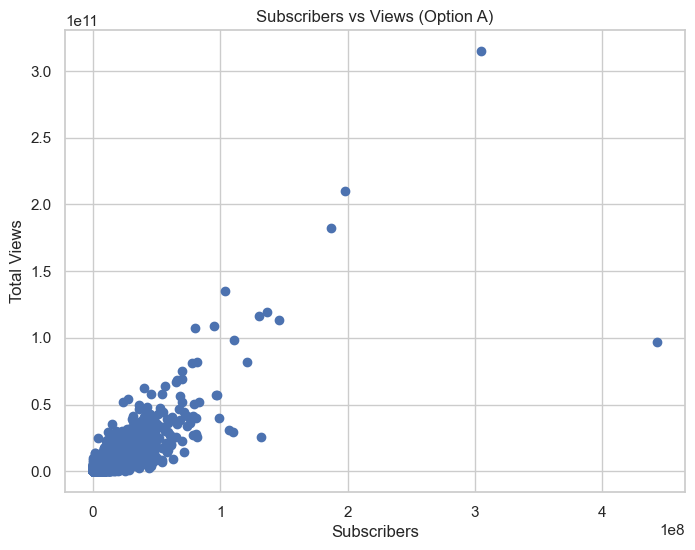

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df_unique['subscriber_count'], df_unique['view_count'])
plt.xlabel("Subscribers")
plt.ylabel("Total Views")
plt.title("Subscribers vs Views (Option A)")
plt.show()

# 🔹 Option B — Aggregated by Channel

In [6]:

df_agg = df.groupby('channel_name').agg({
    'category': lambda x: x.mode()[0],
    'view_count': 'max',
    'subscriber_count': 'max',
    'video_count': 'max',
    'views_last_30_days': 'mean',
    'videos_last_30_days': 'mean',
    'channel_age_years': 'max',
    'country': lambda x: x.mode()[0]
}).reset_index()

df_agg.head()

,channel_name,category,view_count,subscriber_count,video_count,views_last_30_days,videos_last_30_days,channel_age_years,country
0,Cement Craft Ideas - DIY Creations,Hobby,49435372,634000,78,155815.0,7.0,7.62,US
1,bleedem,Electronic music,556817004,2290000,14,0.0,0.0,7.65,Unknown
2,#Mentale Zuflucht,Entertainment,910092875,1310000,1649,475005.0,12.0,9.08,Unknown
3,#Mind Warehouse,Lifestyle (sociology),2268827209,8490000,960,3981532.0,21.0,12.25,US
4,#Sport Channel,Boxing,78339613,136000,48,0.0,0.0,10.70,US


### Heatmap — Aggregated Dataset

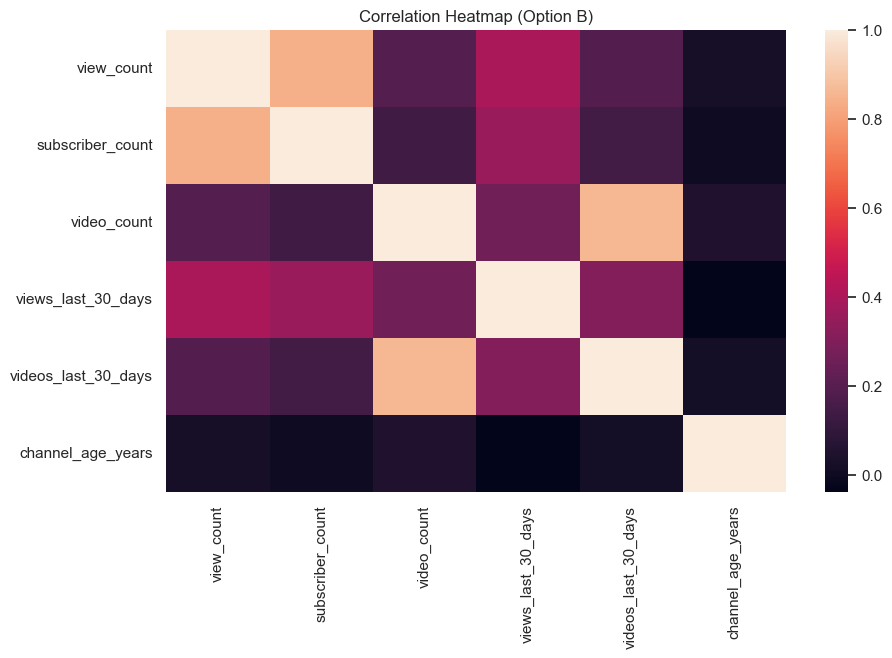

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df_agg.select_dtypes(include=np.number).corr(), annot=False)
plt.title("Correlation Heatmap (Option B)")
plt.show()

### Scatter: Video Count vs Total Views

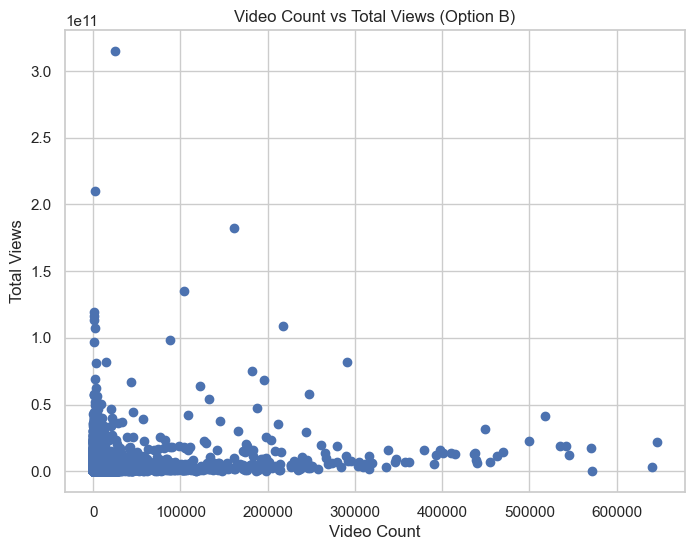

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df_agg['video_count'], df_agg['view_count'])
plt.xlabel("Video Count")
plt.ylabel("Total Views")
plt.title("Video Count vs Total Views (Option B)")
plt.show()

# 🔹 Option C — Category-Expanded Dataset

In [9]:
df_c = df.copy()
df_c.head()

,channel_name,view_count,category,country,subscriber_count,created_date,video_count,videos_last_30_days,views_last_30_days,view_count_log1p,subscriber_count_log1p,video_count_log1p,videos_last_30_days_log1p,views_last_30_days_log1p,channel_created_year,channel_age_years
0,BLACKPINK,39962585446,Music of Asia,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
1,BLACKPINK,39962585446,Pop music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
2,BLACKPINK,39962585446,Music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
3,BLACKPINK,39962585446,Electronic music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
4,HYBE LABELS,41604896923,Hip hop music,KR,78700000,2008-06-04 08:23:22+00:00,2817,79,46074833,24.451484,18.181154,7.943783,4.382027,17.645777,2008,17.43


### Boxplot — Views by Category

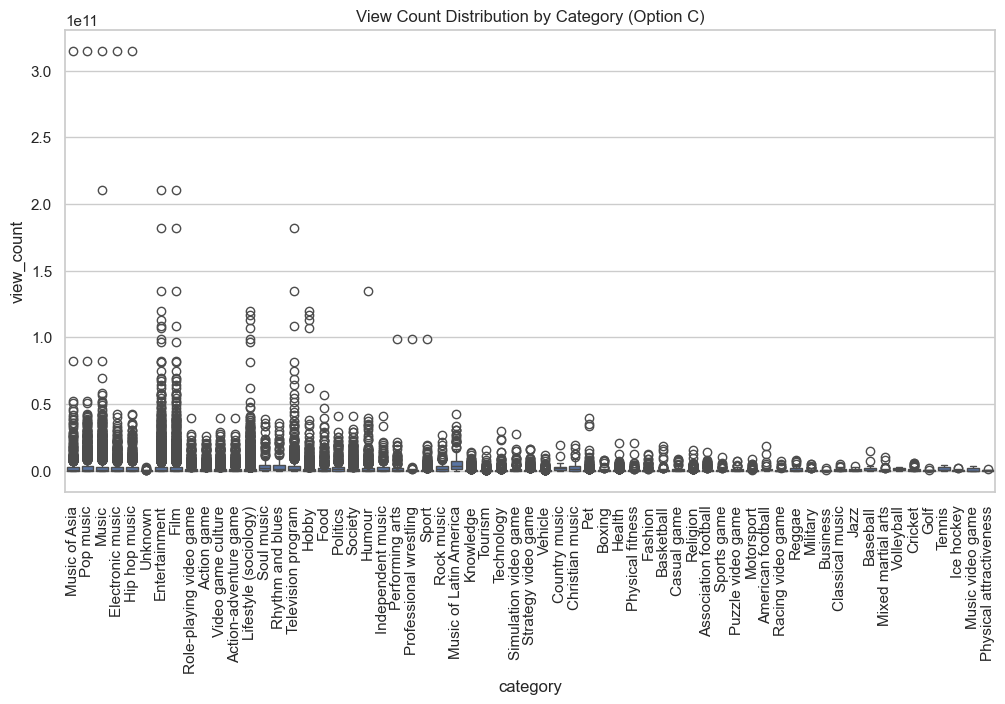

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_c, x='category', y='view_count')
plt.xticks(rotation=90)
plt.title("View Count Distribution by Category (Option C)")
plt.show()

### Bar — Category vs Mean Subscriber Count

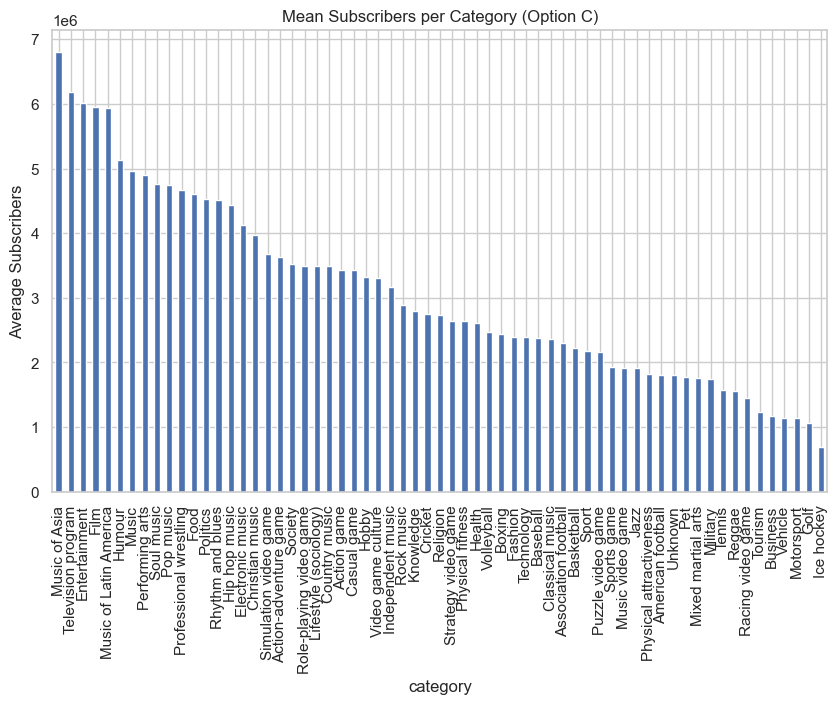

In [11]:
cat_subs = df_c.groupby('category')['subscriber_count'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
cat_subs.plot(kind='bar')
plt.ylabel("Average Subscribers")
plt.title("Mean Subscribers per Category (Option C)")
plt.show()